# WR Draft season features

## tl;dr

This notebook aggregates the validated WR weekly Silver facts into a Draft Analysis Gold dataset at one row per `player_id + season` for the 2023–2025 regular seasons.

The output contains **753 WR player-seasons and 85 columns** across three season partitions. It preserves every observed WR season, including 46 seasons without weekly-stat evidence. A documented eligibility rule identifies 285 seasons with at least eight observed games and 40 targets for within-season percentile comparisons; ineligible rows remain in the dataset with null percentiles.

Season totals, team changes, opportunity shares, efficiency rates, and full-PPR scoring are calculated from explicit components. Conventional `air_yards_share` and target-linked `target_air_yards_share` remain separate. All source reconciliation, scoring, eligibility, grain, and Parquet round-trip checks pass.

## Context & Methods

### Scope

- Seasons: 2023–2025
- Season type: regular season only
- Input: season-partitioned `silver_wr_week`
- Output: season-partitioned `gold/draft/wr_season_features`
- Output grain: `player_id + season`
- Default scoring: full PPR

This is the first decision-oriented Gold prototype. It summarizes what each WR demonstrated across a season while retaining the denominators and scoring components needed to audit the derived features.

### Key assumptions

- Every contextual WR season remains in Gold, even if it is not eligible for percentile comparisons.
- Traded players have one combined season row. `teams_played_for` preserves chronological team order, and `final_team` is the team on the latest observed week.
- `games_observed` counts distinct regular-season games represented in WR Silver; it does not manufacture roster-only or bye-week rows.
- Player opportunity shares are ratios of season totals, not averages of weekly shares. Their team denominators cover the same observed games as the player numerator.
- `air_yards_share` uses team passing air yards. `target_air_yards_share` uses team air yards attached to identified targets.
- Efficiency rates are null when their denominator is zero. Fantasy points remain null when a season has no weekly-stat production evidence.
- Percentiles are calculated within season only among WRs with at least eight observed games and 40 targets. Ineligible rows remain present with null percentile fields.

## Data

### 1. Set up paths, grain, and feature groups

The complete output order is declared before transformation so the persisted schema is easy to review and test.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


SEASONS = [2023, 2024, 2025]
GOLD_GRAIN = ["player_id", "season"]
TEAM_WEEK_GRAIN = ["team", "season", "week"]

MIN_PERCENTILE_GAMES = 8
MIN_PERCENTILE_TARGETS = 40

# Find the repository root whether this runs from Jupyter or nbconvert.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "ROADMAP.md").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "ROADMAP.md").exists():
            PROJECT_ROOT = parent
            break
    else:
        raise RuntimeError("Could not locate the repository root.")

SILVER_WR_WEEK_DIR = PROJECT_ROOT / "data/silver/wr_week"
GOLD_WR_SEASON_DIR = PROJECT_ROOT / "data/gold/draft/wr_season_features"

WR_INPUT_COLUMNS = [
    "player_id",
    "game_id",
    "season",
    "week",
    "season_type",
    "team",
    "display_name",
    "has_stat_record",
    "has_snap_record",
    "participated_game",
    "offensive_participant",
    "offense_snaps",
    "rushing_yards",
    "rushing_touchdowns",
    "rushing_first_downs",
    "rushing_2pt_conversions",
    "receptions",
    "receiving_yards",
    "receiving_touchdowns",
    "receiving_yards_after_catch",
    "receiving_first_downs",
    "receiving_2pt_conversions",
    "fumbles",
    "fumbles_lost",
    "special_teams_touchdowns",
    "pbp_targets",
    "pbp_target_air_yards",
    "red_zone_targets",
    "goal_line_targets",
    "end_zone_targets",
    "pbp_non_kneel_rush_attempts",
    "red_zone_rush_attempts",
    "goal_line_rush_attempts",
    "team_targets",
    "team_passing_air_yards",
    "team_air_yards",
    "team_red_zone_targets",
    "team_goal_line_targets",
    "team_end_zone_targets",
    "team_non_kneel_rush_attempts",
    "team_red_zone_rush_attempts",
    "team_goal_line_rush_attempts",
]

IDENTITY_COLUMNS = [
    "player_id",
    "season",
    "display_name",
    "position",
    "teams_played_for",
    "team_count",
    "final_team",
]

PARTICIPATION_COLUMNS = [
    "games_observed",
    "games_with_stat_record",
    "games_with_snap_record",
    "games_participated",
    "games_offensive_participant",
    "offense_snaps",
    "offense_snaps_per_game",
]

PRODUCTION_OPPORTUNITY_COLUMNS = [
    "targets",
    "receptions",
    "receiving_yards",
    "receiving_touchdowns",
    "receiving_first_downs",
    "receiving_2pt_conversions",
    "receiving_air_yards",
    "receiving_yards_after_catch",
    "rushing_attempts",
    "rushing_yards",
    "rushing_touchdowns",
    "rushing_first_downs",
    "rushing_2pt_conversions",
    "fumbles",
    "fumbles_lost",
    "special_teams_touchdowns",
    "red_zone_targets",
    "goal_line_targets",
    "end_zone_targets",
    "red_zone_rush_attempts",
    "goal_line_rush_attempts",
]

TEAM_DENOMINATOR_COLUMNS = [
    "team_targets",
    "team_passing_air_yards",
    "team_target_air_yards",
    "team_red_zone_targets",
    "team_goal_line_targets",
    "team_end_zone_targets",
    "team_non_kneel_rush_attempts",
    "team_red_zone_rush_attempts",
    "team_goal_line_rush_attempts",
]

SHARE_COLUMNS = [
    "target_share",
    "air_yards_share",
    "target_air_yards_share",
    "red_zone_target_share",
    "goal_line_target_share",
    "end_zone_target_share",
    "rush_attempt_share",
    "red_zone_rush_share",
    "goal_line_rush_share",
]

EFFICIENCY_COLUMNS = [
    "catch_rate",
    "receiving_yards_per_target",
    "receiving_yards_per_reception",
    "average_depth_of_target",
    "yards_after_catch_per_reception",
    "receiving_first_down_rate",
    "receiving_touchdown_rate",
    "rushing_yards_per_attempt",
]

PER_GAME_COLUMNS = [
    "targets_per_game",
    "receptions_per_game",
    "receiving_yards_per_game",
    "receiving_touchdowns_per_game",
    "receiving_air_yards_per_game",
    "red_zone_targets_per_game",
    "total_touchdowns_per_game",
    "ppr_fantasy_points_per_game",
]

FANTASY_POINT_COLUMNS = [
    "receiving_fantasy_points",
    "rushing_fantasy_points",
    "special_teams_fantasy_points",
    "fumble_lost_points",
    "ppr_fantasy_points",
]

PERCENTILE_DEFINITIONS = {
    "offense_snaps_percentile": "offense_snaps",
    "targets_percentile": "targets",
    "target_share_percentile": "target_share",
    "air_yards_share_percentile": "air_yards_share",
    "target_air_yards_share_percentile": "target_air_yards_share",
    "receiving_yards_percentile": "receiving_yards",
    "receiving_yards_per_game_percentile": "receiving_yards_per_game",
    "receiving_yards_per_target_percentile": "receiving_yards_per_target",
    "red_zone_targets_percentile": "red_zone_targets",
    "ppr_fantasy_points_per_game_percentile": "ppr_fantasy_points_per_game",
}

GOLD_COLUMNS = [
    *IDENTITY_COLUMNS,
    *PARTICIPATION_COLUMNS,
    *PRODUCTION_OPPORTUNITY_COLUMNS,
    *TEAM_DENOMINATOR_COLUMNS,
    *SHARE_COLUMNS,
    *EFFICIENCY_COLUMNS,
    *PER_GAME_COLUMNS,
    *FANTASY_POINT_COLUMNS,
    "percentile_eligible",
    *PERCENTILE_DEFINITIONS.keys(),
]

assert len(WR_INPUT_COLUMNS) == 42
assert len(GOLD_COLUMNS) == 85
assert len(GOLD_COLUMNS) == len(set(GOLD_COLUMNS))

pd.set_option("display.max_columns", 90)

### 2. Define the calculation contracts

The contracts state the numerator and denominator choices before any features are calculated. Season shares use summed components rather than averaging weekly percentages.

In [2]:
share_contract = pd.DataFrame(
    [
        ["target_share", "targets", "team_targets"],
        ["air_yards_share", "receiving_air_yards", "team_passing_air_yards"],
        ["target_air_yards_share", "receiving_air_yards", "team_target_air_yards"],
        ["red_zone_target_share", "red_zone_targets", "team_red_zone_targets"],
        ["goal_line_target_share", "goal_line_targets", "team_goal_line_targets"],
        ["end_zone_target_share", "end_zone_targets", "team_end_zone_targets"],
        ["rush_attempt_share", "rushing_attempts", "team_non_kneel_rush_attempts"],
        ["red_zone_rush_share", "red_zone_rush_attempts", "team_red_zone_rush_attempts"],
        ["goal_line_rush_share", "goal_line_rush_attempts", "team_goal_line_rush_attempts"],
    ],
    columns=["feature", "season_numerator", "season_denominator"],
)

efficiency_contract = pd.DataFrame(
    [
        ["catch_rate", "receptions", "targets"],
        ["receiving_yards_per_target", "receiving_yards", "targets"],
        ["receiving_yards_per_reception", "receiving_yards", "receptions"],
        ["average_depth_of_target", "receiving_air_yards", "targets"],
        ["yards_after_catch_per_reception", "receiving_yards_after_catch", "receptions"],
        ["receiving_first_down_rate", "receiving_first_downs", "receptions"],
        ["receiving_touchdown_rate", "receiving_touchdowns", "targets"],
        ["rushing_yards_per_attempt", "rushing_yards", "rushing_attempts"],
    ],
    columns=["feature", "season_numerator", "season_denominator"],
)

share_contract

,feature,season_numerator,season_denominator
0,target_share,targets,team_targets
1,air_yards_share,receiving_air_yards,team_passing_air_yards
2,target_air_yards_share,receiving_air_yards,team_target_air_yards
3,red_zone_target_share,red_zone_targets,team_red_zone_targets
4,goal_line_target_share,goal_line_targets,team_goal_line_targets
5,end_zone_target_share,end_zone_targets,team_end_zone_targets
6,rush_attempt_share,rushing_attempts,team_non_kneel_rush_attempts
7,red_zone_rush_share,red_zone_rush_attempts,team_red_zone_rush_attempts
8,goal_line_rush_share,goal_line_rush_attempts,team_goal_line_rush_attempts


In [3]:
scoring_contract = pd.DataFrame(
    [
        ["reception", 1.0],
        ["receiving yard", 0.1],
        ["receiving touchdown", 6.0],
        ["rushing yard", 0.1],
        ["rushing touchdown", 6.0],
        ["two-point conversion", 2.0],
        ["fumble lost", -2.0],
        ["special-teams touchdown", 6.0],
    ],
    columns=["event", "full_ppr_points"],
)

scoring_contract

,event,full_ppr_points
0,reception,1.0
1,receiving yard,0.1
2,receiving touchdown,6.0
3,rushing yard,0.1
4,rushing touchdown,6.0
5,two-point conversion,2.0
6,fumble lost,-2.0
7,special-teams touchdown,6.0


### 3. Load the WR Silver partitions

In [4]:
wr_week_paths = sorted(SILVER_WR_WEEK_DIR.glob("*.parquet"))

assert len(wr_week_paths) == len(SEASONS)

wr_week = pd.concat(
    [pd.read_parquet(path, columns=WR_INPUT_COLUMNS) for path in wr_week_paths],
    ignore_index=True,
)

input_summary = pd.DataFrame(
    [
        [
            "silver_wr_week",
            len(wr_week),
            61,
            len(wr_week.columns),
            len(wr_week_paths),
        ]
    ],
    columns=["input", "rows", "columns_available", "columns_selected", "files"],
)

assert set(wr_week["season"].unique()) == set(SEASONS)
input_summary

,input,rows,columns_available,columns_selected,files
0,silver_wr_week,8881,61,42,3


## Results

### 4. Validate the input grain and select regular-season observations

Postseason rows remain in Silver but do not enter the Draft season profile. The Gold population is therefore defined explicitly before aggregation.

In [5]:
SILVER_WR_GRAIN = ["player_id", "season", "week", "team"]

assert wr_week[SILVER_WR_GRAIN].notna().all().all()
assert not wr_week.duplicated(SILVER_WR_GRAIN).any()

wr_regular = (
    wr_week.loc[wr_week["season_type"].eq("REG")]
    .sort_values(["player_id", "season", "week", "team"])
    .reset_index(drop=True)
)

assert wr_regular["game_id"].notna().all()
assert not wr_regular.duplicated(SILVER_WR_GRAIN).any()
assert not wr_regular.duplicated(["player_id", "season", "game_id"]).any()

regular_population_summary = (
    wr_regular.groupby("season", dropna=False)
    .agg(
        player_weeks=("game_id", "size"),
        player_seasons=("player_id", "nunique"),
        teams=("team", "nunique"),
    )
    .reset_index()
)

regular_population_summary

,season,player_weeks,player_seasons,teams
0,2023,2865,245,32
1,2024,2797,252,32
2,2025,2813,256,32


### 5. Build season identity and team context

Players who change teams remain one player-season. The team list follows first observed appearance, and the final team comes from the latest observed regular-season week.

In [6]:
identity_validation = (
    wr_regular.groupby(GOLD_GRAIN, dropna=False)
    .agg(display_names=("display_name", "nunique"))
    .reset_index()
)

assert identity_validation["display_names"].le(1).all()

season_context = (
    wr_regular.groupby(GOLD_GRAIN, sort=False, dropna=False)
    .agg(
        display_name=("display_name", "last"),
        teams_played_for=("team", lambda values: ", ".join(dict.fromkeys(values))),
        team_count=("team", "nunique"),
        final_team=("team", "last"),
    )
    .reset_index()
)
season_context.insert(3, "position", "WR")

assert not season_context.duplicated(GOLD_GRAIN).any()
assert season_context["display_name"].notna().all()
assert season_context.apply(
    lambda row: len(row["teams_played_for"].split(", ")) == row["team_count"],
    axis=1,
).all()
assert season_context.apply(
    lambda row: row["final_team"] in row["teams_played_for"].split(", "),
    axis=1,
).all()

season_context.head()

,player_id,season,display_name,position,teams_played_for,team_count,final_team
0,00-0026293,2023,Matthew Slater,WR,NE,1,NE
1,00-0027944,2023,Julio Jones,WR,PHI,1,PHI
2,00-0028002,2023,Randall Cobb,WR,NYJ,1,NYJ
3,00-0029293,2023,Marvin Jones,WR,DET,1,DET
4,00-0030035,2023,Adam Thielen,WR,CAR,1,CAR


### 6. Aggregate participation, production, and opportunity

The small aggregation helpers make two null rules explicit: source statistics stay null when an entire season lacks stat evidence, while nullable participation flags count only confirmed `True` values.

In [7]:
def sum_with_minimum_evidence(values):
    return values.sum(min_count=1)


def count_confirmed_true(values):
    return values.fillna(False).sum()


season_totals = (
    wr_regular.groupby(GOLD_GRAIN, sort=False, dropna=False)
    .agg(
        games_observed=("game_id", "nunique"),
        games_with_stat_record=("has_stat_record", "sum"),
        games_with_snap_record=("has_snap_record", "sum"),
        games_participated=("participated_game", count_confirmed_true),
        games_offensive_participant=("offensive_participant", count_confirmed_true),
        offense_snaps=("offense_snaps", sum_with_minimum_evidence),
        targets=("pbp_targets", "sum"),
        receptions=("receptions", sum_with_minimum_evidence),
        receiving_yards=("receiving_yards", sum_with_minimum_evidence),
        receiving_touchdowns=("receiving_touchdowns", sum_with_minimum_evidence),
        receiving_first_downs=("receiving_first_downs", sum_with_minimum_evidence),
        receiving_2pt_conversions=("receiving_2pt_conversions", sum_with_minimum_evidence),
        receiving_air_yards=("pbp_target_air_yards", "sum"),
        receiving_yards_after_catch=("receiving_yards_after_catch", sum_with_minimum_evidence),
        rushing_attempts=("pbp_non_kneel_rush_attempts", "sum"),
        rushing_yards=("rushing_yards", sum_with_minimum_evidence),
        rushing_touchdowns=("rushing_touchdowns", sum_with_minimum_evidence),
        rushing_first_downs=("rushing_first_downs", sum_with_minimum_evidence),
        rushing_2pt_conversions=("rushing_2pt_conversions", sum_with_minimum_evidence),
        fumbles=("fumbles", sum_with_minimum_evidence),
        fumbles_lost=("fumbles_lost", sum_with_minimum_evidence),
        special_teams_touchdowns=("special_teams_touchdowns", sum_with_minimum_evidence),
        red_zone_targets=("red_zone_targets", "sum"),
        goal_line_targets=("goal_line_targets", "sum"),
        end_zone_targets=("end_zone_targets", "sum"),
        red_zone_rush_attempts=("red_zone_rush_attempts", "sum"),
        goal_line_rush_attempts=("goal_line_rush_attempts", "sum"),
        team_targets=("team_targets", "sum"),
        team_passing_air_yards=("team_passing_air_yards", "sum"),
        team_target_air_yards=("team_air_yards", "sum"),
        team_red_zone_targets=("team_red_zone_targets", "sum"),
        team_goal_line_targets=("team_goal_line_targets", "sum"),
        team_end_zone_targets=("team_end_zone_targets", "sum"),
        team_non_kneel_rush_attempts=("team_non_kneel_rush_attempts", "sum"),
        team_red_zone_rush_attempts=("team_red_zone_rush_attempts", "sum"),
        team_goal_line_rush_attempts=("team_goal_line_rush_attempts", "sum"),
    )
    .reset_index()
)

wr_season_features = season_context.merge(
    season_totals,
    on=GOLD_GRAIN,
    how="inner",
    validate="one_to_one",
)

assert len(wr_season_features) == wr_regular.groupby(GOLD_GRAIN).ngroups
assert not wr_season_features.duplicated(GOLD_GRAIN).any()

wr_season_features[[
    "season",
    "display_name",
    "games_observed",
    "targets",
    "receiving_yards",
]].head()

,season,display_name,games_observed,targets,receiving_yards
0,2023,Matthew Slater,16,0,0
1,2023,Julio Jones,11,19,74
2,2023,Randall Cobb,11,17,39
3,2023,Marvin Jones,6,10,35
4,2023,Adam Thielen,17,137,1014


### 7. Reconcile season totals to WR Silver

Gold changes the grain, not the underlying totals. Canonical PBP opportunity and nullable weekly-stat production must sum back to the selected regular-season Silver population.

In [8]:
RECONCILIATION_COLUMNS = {
    "targets": "pbp_targets",
    "receptions": "receptions",
    "receiving_yards": "receiving_yards",
    "receiving_touchdowns": "receiving_touchdowns",
    "receiving_air_yards": "pbp_target_air_yards",
    "rushing_attempts": "pbp_non_kneel_rush_attempts",
    "rushing_yards": "rushing_yards",
    "rushing_touchdowns": "rushing_touchdowns",
    "red_zone_targets": "red_zone_targets",
    "goal_line_targets": "goal_line_targets",
    "end_zone_targets": "end_zone_targets",
}

reconciliation_records = []
for gold_column, silver_column in RECONCILIATION_COLUMNS.items():
    silver_total = wr_regular[silver_column].sum()
    gold_total = wr_season_features[gold_column].sum()
    difference = gold_total - silver_total
    reconciliation_records.append(
        [gold_column, silver_total, gold_total, difference]
    )

season_total_reconciliation = pd.DataFrame(
    reconciliation_records,
    columns=["metric", "Silver_regular_total", "Gold_season_total", "difference"],
)

assert np.isclose(
    season_total_reconciliation["difference"].astype("float64"),
    0,
    rtol=0,
    atol=1e-12,
).all()

season_total_reconciliation

,metric,Silver_regular_total,Gold_season_total,difference
0,targets,30303.0,30303.0,0.0
1,receptions,19086.0,19086.0,0.0
2,receiving_yards,240332.0,240332.0,0.0
3,receiving_touchdowns,1493.0,1493.0,0.0
4,receiving_air_yards,326267.0,326267.0,0.0
5,rushing_attempts,1277.0,1277.0,0.0
6,rushing_yards,7025.0,7025.0,0.0
7,rushing_touchdowns,50.0,50.0,0.0
8,red_zone_targets,3832.0,3832.0,0.0
9,goal_line_targets,828.0,828.0,0.0


### 8. Calculate season opportunity shares

Each share divides summed season opportunity by the corresponding summed team denominator over the player’s observed games. A zero denominator produces null; observed zero player opportunity with a valid denominator produces zero.

In [9]:
SHARE_DEFINITIONS = {
    row.feature: (row.season_numerator, row.season_denominator)
    for row in share_contract.itertuples(index=False)
}

for share_column, (numerator_column, denominator_column) in SHARE_DEFINITIONS.items():
    valid_denominator = wr_season_features[denominator_column].ne(0)
    wr_season_features[share_column] = (
        wr_season_features[numerator_column]
        .div(wr_season_features[denominator_column].where(valid_denominator))
        .astype("Float64")
    )
    assert wr_season_features.loc[~valid_denominator, share_column].isna().all()

bounded_share_columns = [
    "target_share",
    "red_zone_target_share",
    "goal_line_target_share",
    "end_zone_target_share",
    "rush_attempt_share",
    "red_zone_rush_share",
    "goal_line_rush_share",
]

for column in bounded_share_columns:
    assert wr_season_features[column].dropna().between(0, 1, inclusive="both").all()

share_summary = pd.DataFrame(
    [
        {
            "share": share_column,
            "non_null_rows": wr_season_features[share_column].notna().sum(),
            "minimum": wr_season_features[share_column].min(),
            "maximum": wr_season_features[share_column].max(),
        }
        for share_column in SHARE_COLUMNS
    ]
)

share_summary

,share,non_null_rows,minimum,maximum
0,target_share,753,0.000000,0.358242
1,air_yards_share,753,-0.011837,0.555556
2,target_air_yards_share,753,-0.013249,0.600000
3,red_zone_target_share,751,0.000000,1.000000
4,goal_line_target_share,716,0.000000,0.695652
5,end_zone_target_share,744,0.000000,0.600000
6,rush_attempt_share,753,0.000000,0.108247
7,red_zone_rush_share,751,0.000000,0.200000
8,goal_line_rush_share,727,0.000000,0.250000


### 9. Calculate efficiency and per-game features

Ratios are calculated from season totals. They are not weekly averages, and zero denominators remain null rather than being converted to zero efficiency.

In [10]:
RATIO_DEFINITIONS = {
    **{
        row.feature: (row.season_numerator, row.season_denominator)
        for row in efficiency_contract.itertuples(index=False)
    },
    "offense_snaps_per_game": ("offense_snaps", "games_observed"),
    "targets_per_game": ("targets", "games_observed"),
    "receptions_per_game": ("receptions", "games_observed"),
    "receiving_yards_per_game": ("receiving_yards", "games_observed"),
    "receiving_touchdowns_per_game": ("receiving_touchdowns", "games_observed"),
    "receiving_air_yards_per_game": ("receiving_air_yards", "games_observed"),
    "red_zone_targets_per_game": ("red_zone_targets", "games_observed"),
}

for feature, (numerator_column, denominator_column) in RATIO_DEFINITIONS.items():
    valid_denominator = wr_season_features[denominator_column].ne(0)
    wr_season_features[feature] = (
        wr_season_features[numerator_column]
        .div(wr_season_features[denominator_column].where(valid_denominator))
        .astype("Float64")
    )

assert wr_season_features["games_observed"].gt(0).all()
wr_season_features[[
    "season",
    "display_name",
    "catch_rate",
    "receiving_yards_per_target",
    "average_depth_of_target",
]].head()

,season,display_name,catch_rate,receiving_yards_per_target,average_depth_of_target
0,2023,Matthew Slater,<NA>,<NA>,<NA>
1,2023,Julio Jones,0.578947,3.894737,6.894737
2,2023,Randall Cobb,0.294118,2.294118,9.705882
3,2023,Marvin Jones,0.5,3.5,8.0
4,2023,Adam Thielen,0.751825,7.40146,7.722628


### 10. Calculate full-PPR fantasy scoring

The component columns keep the scoring model auditable and reusable. No yardage or reception bonuses are applied.

In [11]:
wr_season_features["receiving_fantasy_points"] = (
    wr_season_features["receptions"]
    + 0.1 * wr_season_features["receiving_yards"]
    + 6 * wr_season_features["receiving_touchdowns"]
    + 2 * wr_season_features["receiving_2pt_conversions"]
).astype("Float64")

wr_season_features["rushing_fantasy_points"] = (
    0.1 * wr_season_features["rushing_yards"]
    + 6 * wr_season_features["rushing_touchdowns"]
    + 2 * wr_season_features["rushing_2pt_conversions"]
).astype("Float64")

wr_season_features["special_teams_fantasy_points"] = (
    6 * wr_season_features["special_teams_touchdowns"]
).astype("Float64")

wr_season_features["fumble_lost_points"] = (
    -2 * wr_season_features["fumbles_lost"]
).astype("Float64")

wr_season_features["ppr_fantasy_points"] = wr_season_features[
    [
        "receiving_fantasy_points",
        "rushing_fantasy_points",
        "special_teams_fantasy_points",
        "fumble_lost_points",
    ]
].sum(axis=1, min_count=4).astype("Float64")

wr_season_features["total_touchdowns_per_game"] = (
    wr_season_features[
        [
            "receiving_touchdowns",
            "rushing_touchdowns",
            "special_teams_touchdowns",
        ]
    ]
    .sum(axis=1, min_count=1)
    .div(wr_season_features["games_observed"])
    .astype("Float64")
)

wr_season_features["ppr_fantasy_points_per_game"] = (
    wr_season_features["ppr_fantasy_points"]
    .div(wr_season_features["games_observed"])
    .astype("Float64")
)

scoring_check = wr_season_features[
    [
        "receiving_fantasy_points",
        "rushing_fantasy_points",
        "special_teams_fantasy_points",
        "fumble_lost_points",
    ]
].sum(axis=1, min_count=4)

assert np.isclose(
    wr_season_features["ppr_fantasy_points"].dropna().astype("float64"),
    scoring_check.dropna().astype("float64"),
    rtol=0,
    atol=1e-12,
).all()

### 11. Apply percentile eligibility and within-season ranks

Eligibility controls only the comparison population. It never removes a player-season from the dataset. Percentiles run from values near zero to one, with higher values representing more of the named metric.

In [12]:
wr_season_features["percentile_eligible"] = (
    wr_season_features["games_observed"].ge(MIN_PERCENTILE_GAMES)
    & wr_season_features["targets"].ge(MIN_PERCENTILE_TARGETS)
)

for percentile_column, metric_column in PERCENTILE_DEFINITIONS.items():
    wr_season_features[percentile_column] = pd.Series(
        pd.NA,
        index=wr_season_features.index,
        dtype="Float64",
    )
    eligible_metric = (
        wr_season_features["percentile_eligible"]
        & wr_season_features[metric_column].notna()
    )
    wr_season_features.loc[eligible_metric, percentile_column] = (
        wr_season_features.loc[eligible_metric]
        .groupby("season")[metric_column]
        .rank(method="average", pct=True)
        .astype("Float64")
    )

assert not wr_season_features.loc[
    ~wr_season_features["percentile_eligible"],
    list(PERCENTILE_DEFINITIONS),
].notna().any().any()

eligibility_summary = (
    wr_season_features.groupby("season", dropna=False)
    .agg(
        player_seasons=("player_id", "size"),
        percentile_eligible=("percentile_eligible", "sum"),
    )
    .reset_index()
)
eligibility_summary["ineligible_retained"] = (
    eligibility_summary["player_seasons"]
    - eligibility_summary["percentile_eligible"]
)

eligibility_summary

,season,player_seasons,percentile_eligible,ineligible_retained
0,2023,245,94,151
1,2024,252,103,149
2,2025,256,88,168


### 12. Create `gold_wr_season_features`

The final selection enforces the approved 85-column schema and a stable reader-facing column order.

In [13]:
gold_wr_season_features = (
    wr_season_features[GOLD_COLUMNS]
    .sort_values(["season", "display_name", "player_id"])
    .reset_index(drop=True)
)

INTEGER_COLUMNS = [
    "team_count",
    "games_observed",
    "games_with_stat_record",
    "games_with_snap_record",
    "games_participated",
    "games_offensive_participant",
    "offense_snaps",
    "targets",
    "receptions",
    "receiving_yards",
    "receiving_touchdowns",
    "receiving_first_downs",
    "receiving_2pt_conversions",
    "rushing_attempts",
    "rushing_yards",
    "rushing_touchdowns",
    "rushing_first_downs",
    "rushing_2pt_conversions",
    "fumbles",
    "fumbles_lost",
    "special_teams_touchdowns",
    "red_zone_targets",
    "goal_line_targets",
    "end_zone_targets",
    "red_zone_rush_attempts",
    "goal_line_rush_attempts",
    "team_targets",
    "team_red_zone_targets",
    "team_goal_line_targets",
    "team_end_zone_targets",
    "team_non_kneel_rush_attempts",
    "team_red_zone_rush_attempts",
    "team_goal_line_rush_attempts",
]

for column in INTEGER_COLUMNS:
    gold_wr_season_features[column] = gold_wr_season_features[column].astype("Int64")

gold_wr_season_features["season"] = gold_wr_season_features["season"].astype("int32")
gold_wr_season_features["percentile_eligible"] = gold_wr_season_features[
    "percentile_eligible"
].astype("boolean")

assert gold_wr_season_features.columns.tolist() == GOLD_COLUMNS
assert len(gold_wr_season_features.columns) == 85
assert gold_wr_season_features[GOLD_GRAIN].notna().all().all()
assert not gold_wr_season_features.duplicated(GOLD_GRAIN).any()

pd.DataFrame(
    {
        "dataset": ["gold_wr_season_features"],
        "rows": [len(gold_wr_season_features)],
        "columns": [len(gold_wr_season_features.columns)],
        "grain": [" + ".join(GOLD_GRAIN)],
        "duplicate_grain_rows": [gold_wr_season_features.duplicated(GOLD_GRAIN).sum()],
        "null_grain_rows": [gold_wr_season_features[GOLD_GRAIN].isna().any(axis=1).sum()],
    }
)

,dataset,rows,columns,grain,duplicate_grain_rows,null_grain_rows
0,gold_wr_season_features,753,85,player_id + season,0,0


### 13. Validate null behavior and percentile bounds

Seasons without stat evidence retain null production and fantasy scoring. PBP opportunity remains observed, so those rows can still show zero targets rather than an invented statistical value.

In [14]:
no_stat_seasons = gold_wr_season_features["games_with_stat_record"].eq(0)

assert gold_wr_season_features.loc[no_stat_seasons, "receptions"].isna().all()
assert gold_wr_season_features.loc[no_stat_seasons, "receiving_yards"].isna().all()
assert gold_wr_season_features.loc[no_stat_seasons, "ppr_fantasy_points"].isna().all()
assert gold_wr_season_features.loc[no_stat_seasons, "targets"].eq(0).all()

for column in PERCENTILE_DEFINITIONS:
    assert gold_wr_season_features[column].dropna().between(0, 1, inclusive="both").all()

assert gold_wr_season_features.loc[
    gold_wr_season_features["percentile_eligible"],
    list(PERCENTILE_DEFINITIONS),
].notna().all().all()

null_behavior_summary = pd.DataFrame(
    [
        [
            "player-seasons without weekly-stat evidence",
            no_stat_seasons.sum(),
            gold_wr_season_features.loc[no_stat_seasons, "ppr_fantasy_points"].isna().sum(),
            gold_wr_season_features.loc[no_stat_seasons, "targets"].eq(0).sum(),
        ]
    ],
    columns=["population", "rows", "null_fantasy_points", "zero_observed_targets"],
)

null_behavior_summary

,population,rows,null_fantasy_points,zero_observed_targets
0,player-seasons without weekly-stat evidence,46,46,46


### 14. Check traded-player aggregation

Multiple teams across a season are valid. The single Gold row keeps the chronological team path, count, and final observed team.

In [15]:
traded_player_seasons = (
    gold_wr_season_features.loc[gold_wr_season_features["team_count"].gt(1)]
    [
        [
            "season",
            "display_name",
            "teams_played_for",
            "team_count",
            "final_team",
            "games_observed",
            "targets",
        ]
    ]
    .sort_values(["season", "display_name"])
    .reset_index(drop=True)
)

print(f"Combined WR player-seasons with multiple teams: {len(traded_player_seasons):,}")
traded_player_seasons.head(12)

Combined WR player-seasons with multiple teams: 36


,season,display_name,teams_played_for,team_count,final_team,games_observed,targets
0,2023,Chase Claypool,"CHI, MIA",2,MIA,12,21
1,2023,Donovan Peoples-Jones,"CLE, DET",2,DET,15,25
2,2023,Gunner Olszewski,"PIT, NYG",2,NYG,12,1
3,2023,Mecole Hardman,"NYJ, KC",2,KC,11,24
4,2023,Van Jefferson,"LA, ATL",2,ATL,17,43
5,2024,Amari Cooper,"CLE, BUF",2,BUF,14,85
6,2024,Davante Adams,"LV, NYJ",2,NYJ,14,141
7,2024,DeAndre Hopkins,"TEN, KC",2,KC,16,80
8,2024,Dee Williams,"SEA, NYG",2,NYG,13,0
9,2024,Diontae Johnson,"CAR, BAL, HOU",3,HOU,12,67


### 15. Review recognizable WR seasons

The table provides a direct reasonableness check for volume, production, and scoring. It is descriptive rather than a hard-coded external benchmark.

In [16]:
season_leaders = (
    gold_wr_season_features.loc[gold_wr_season_features["ppr_fantasy_points"].notna()]
    .sort_values(["season", "ppr_fantasy_points"], ascending=[True, False])
    .groupby("season", group_keys=False)
    .head(5)
    [
        [
            "season",
            "display_name",
            "games_observed",
            "targets",
            "receptions",
            "receiving_yards",
            "receiving_touchdowns",
            "ppr_fantasy_points",
            "ppr_fantasy_points_per_game",
        ]
    ]
    .reset_index(drop=True)
)

season_leaders

,season,display_name,games_observed,targets,receptions,receiving_yards,receiving_touchdowns,ppr_fantasy_points,ppr_fantasy_points_per_game
0,2023,CeeDee Lamb,17,181,135,1749,12,403.2,23.717647
1,2023,Tyreek Hill,16,171,119,1799,13,376.4,23.525
2,2023,Amon-Ra St. Brown,16,164,119,1515,10,330.9,20.68125
3,2023,Puka Nacua,17,160,105,1486,6,298.5,17.558824
4,2023,A.J. Brown,17,158,106,1456,7,289.6,17.035294
5,2024,Ja'Marr Chase,17,175,127,1708,17,403.0,23.705882
6,2024,Justin Jefferson,17,154,103,1533,10,316.6,18.623529
7,2024,Amon-Ra St. Brown,17,141,115,1263,12,311.9,18.347059
8,2024,Brian Thomas Jr.,17,133,87,1282,10,284.0,16.705882
9,2024,Drake London,17,158,100,1271,9,280.8,16.517647


### 16. Inspect opportunity and scoring together

The chart shows the eligible comparison population. It helps reveal whether high target share translated into high per-game fantasy production without collapsing the two concepts into a composite score.

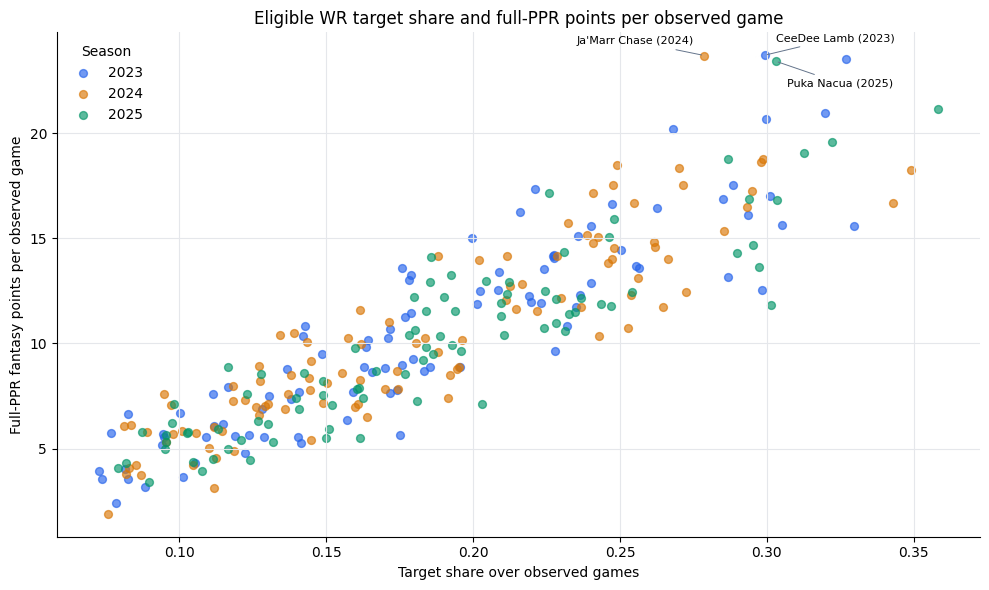

In [17]:
plot_population = gold_wr_season_features.loc[
    gold_wr_season_features["percentile_eligible"]
].copy()

season_colors = {
    2023: "#2563eb",
    2024: "#d97706",
    2025: "#059669",
}

fig, axis = plt.subplots(figsize=(10, 6))

for season in SEASONS:
    season_rows = plot_population.loc[plot_population["season"].eq(season)]
    axis.scatter(
        season_rows["target_share"].astype("float64"),
        season_rows["ppr_fantasy_points_per_game"].astype("float64"),
        label=str(season),
        color=season_colors[season],
        alpha=0.65,
        s=32,
    )

label_rows = (
    plot_population.sort_values(
        ["season", "ppr_fantasy_points_per_game"],
        ascending=[True, False],
    )
    .groupby("season", group_keys=False)
    .head(1)
)
label_offsets = {
    2023: (8, 10),
    2024: (-92, 8),
    2025: (8, -18),
}
for row in label_rows.itertuples(index=False):
    axis.annotate(
        f"{row.display_name} ({row.season})",
        (float(row.target_share), float(row.ppr_fantasy_points_per_game)),
        xytext=label_offsets[row.season],
        textcoords="offset points",
        fontsize=8,
        arrowprops={"arrowstyle": "-", "color": "#64748b", "linewidth": 0.7},
    )

axis.set_title("Eligible WR target share and full-PPR points per observed game")
axis.set_xlabel("Target share over observed games")
axis.set_ylabel("Full-PPR fantasy points per observed game")
axis.grid(color="#e5e7eb", linewidth=0.8)
axis.spines[["top", "right"]].set_visible(False)
axis.legend(title="Season", frameon=False)
fig.tight_layout()
plt.show()

### 17. Persist season-partitioned Gold Parquet

Each partition is written and immediately reloaded. Shape, column order, dtypes, season membership, and the declared player-season grain must survive the round trip.

In [18]:
GOLD_WR_SEASON_DIR.mkdir(parents=True, exist_ok=True)

output_records = []
for season in SEASONS:
    season_partition = (
        gold_wr_season_features.loc[gold_wr_season_features["season"].eq(season)]
        .sort_values(["display_name", "player_id"])
        .reset_index(drop=True)
    )
    output_path = GOLD_WR_SEASON_DIR / f"wr_season_features_{season}.parquet"
    season_partition.to_parquet(output_path, index=False)
    reloaded = pd.read_parquet(output_path)

    assert reloaded.shape == season_partition.shape
    assert reloaded.columns.tolist() == season_partition.columns.tolist()
    assert reloaded.dtypes.astype(str).tolist() == season_partition.dtypes.astype(str).tolist()
    assert set(reloaded["season"].unique()) == {season}
    assert not reloaded.duplicated(GOLD_GRAIN).any()

    output_records.append(
        {
            "dataset": "gold_wr_season_features",
            "season": season,
            "rows": len(reloaded),
            "columns": len(reloaded.columns),
            "eligible_rows": int(reloaded["percentile_eligible"].sum()),
            "grain": " + ".join(GOLD_GRAIN),
            "duplicate_grain_rows": reloaded.duplicated(GOLD_GRAIN).sum(),
            "file_mb": output_path.stat().st_size / 1024**2,
            "round_trip_passed": True,
        }
    )

output_summary = pd.DataFrame(output_records)

assert output_summary["rows"].sum() == len(gold_wr_season_features)
assert output_summary["eligible_rows"].sum() == gold_wr_season_features["percentile_eligible"].sum()
assert output_summary["duplicate_grain_rows"].eq(0).all()
assert output_summary["round_trip_passed"].all()

output_summary

,dataset,season,rows,columns,eligible_rows,grain,duplicate_grain_rows,file_mb,round_trip_passed
0,gold_wr_season_features,2023,245,85,94,player_id + season,0,0.110607,True
1,gold_wr_season_features,2024,252,85,103,player_id + season,0,0.112631,True
2,gold_wr_season_features,2025,256,85,88,player_id + season,0,0.110613,True


In [19]:
print(
    f"Wrote {len(output_summary):,} WR Draft Gold files with "
    f"{output_summary['rows'].sum():,} player-seasons, "
    f"{len(gold_wr_season_features.columns):,} columns, "
    f"{output_summary['eligible_rows'].sum():,} percentile-eligible rows, and "
    f"{output_summary['file_mb'].sum():.2f} MB on disk."
)

Wrote 3 WR Draft Gold files with 753 player-seasons, 85 columns, 285 percentile-eligible rows, and 0.33 MB on disk.


## Takeaways

- `gold_wr_season_features` contains 753 regular-season WR profiles at `player_id + season`: 245 in 2023, 252 in 2024, and 256 in 2025.
- All observed WR seasons remain available. The 46 seasons without weekly-stat evidence preserve null production and fantasy scoring while retaining confirmed zero PBP targets.
- The eight-game and 40-target rule identifies 285 percentile-eligible seasons. All ten percentile columns remain null for the 468 retained ineligible seasons.
- Thirty-six multi-team player-seasons are combined without violating the player-season grain; their chronological team path and final observed team remain visible.
- Full-PPR scoring remains transparent through receiving, rushing, special-teams, and fumble-lost components. The leading totals are CeeDee Lamb with 403.2 in 2023, Ja'Marr Chase with 403.0 in 2024, and Puka Nacua with 375.0 in 2025.
- Conventional and target-linked air-yards shares remain separate season-total ratios, so the Draft application can compare either definition without recalculating them.
- Three 85-column season partitions pass total reconciliation, eligibility, null behavior, schema, dtype, season, grain, and Parquet round-trip checks.